In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

In [3]:
# for prantooshhh

BASE = "/content/drive/My Drive/LABWORKS/CSE422/Project"

if os.path.exists(BASE):
    print("Folder exists!")
else:
    print("Folder not found.")
files = os.listdir(BASE)
print(files)

Folder exists!
['E-commerce Shipping Dataset.gsheet', 'E-commerce Shipping Dataset.csv', 'CSE422 Lab Project Report.gdoc', 'code.ipynb']


In [ ]:
# # RUN THIS (for Dia)

# BASE = "/content/drive/MyDrive/Project"
# if os.path.exists(BASE):
#     print("Folder exists!")
# else:
#     print("Folder not found.")

# files = os.listdir(BASE)
# print(files)

# **EDA**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(f"{BASE}/E-commerce Shipping Dataset.csv")
print("Dataset sample:")
df.head(10)

Dataset sample:


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
5,6,F,Flight,3,1,162,3,medium,F,12,1417,1
6,7,D,Flight,3,4,250,3,low,F,3,2371,1
7,8,F,Flight,4,1,233,2,low,F,48,2804,1
8,9,A,Flight,3,4,150,3,low,F,11,1861,1
9,10,B,Flight,3,2,164,3,medium,F,29,1187,1


In [7]:
m = df.shape
print("Total Features:", m[0])
print("Total Records:", m[1])

Total Features: 10999
Total Records: 12


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


The feature 'Reached.on.Time_Y.N' is expressed with 1 or 0 which acts as True or False. Though the values are numerical, the nature of expression is categorical. So, we need to convert it to categorical feature.

In [9]:
df['Reached.on.Time_Y.N'] = df['Reached.on.Time_Y.N'].astype('object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  object
dtypes: int64(7), object(5)
memory usage: 1.0+ MB


In [11]:
q_data = df.select_dtypes(include='number')
q_features = q_data.columns.tolist()
c_data = df.select_dtypes(include='object')
c_features = c_data.columns.tolist()

print("Total quantative features:", len(q_features))
print("Quantative features are:", ', '.join(q_features))
print()
print("Total categorical features:", len(c_features))
print("Categorical features are:", ', '.join(c_features))

Total quantative features: 7
Quantative features are: ID, Customer_care_calls, Customer_rating, Cost_of_the_Product, Prior_purchases, Discount_offered, Weight_in_gms

Total categorical features: 5
Categorical features are: Warehouse_block, Mode_of_Shipment, Product_importance, Gender, Reached.on.Time_Y.N


## Descriptive Analysis of Quantative and Categorical Features

In [12]:
q_data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,10999.0,5500.000000,3175.282140,1.0,2750.5,5500.0,8249.5,10999.0
Customer_care_calls,10999.0,4.054459,1.141490,2.0,3.0,4.0,5.0,7.0
Customer_rating,10999.0,2.990545,1.413603,1.0,2.0,3.0,4.0,5.0
Cost_of_the_Product,10999.0,210.196836,48.063272,96.0,169.0,214.0,251.0,310.0
Prior_purchases,10999.0,3.567597,1.522860,2.0,3.0,3.0,4.0,10.0
Discount_offered,10999.0,13.373216,16.205527,1.0,4.0,7.0,10.0,65.0
Weight_in_gms,10999.0,3634.016729,1635.377251,1001.0,1839.5,4149.0,5050.0,7846.0


In [13]:
q_data.var()

,0
ID,1.008242e+07
Customer_care_calls,1.302999e+00
Customer_rating,1.998274e+00
Cost_of_the_Product,2.310078e+03
Prior_purchases,2.319103e+00
Discount_offered,2.626191e+02
Weight_in_gms,2.674459e+06


In [14]:
c_data.describe().T

,count,unique,top,freq
Warehouse_block,10999,5,F,3666
Mode_of_Shipment,10999,3,Ship,7462
Product_importance,10999,3,low,5297
Gender,10999,2,F,5545
Reached.on.Time_Y.N,10999,2,1,6563


## Skewness Analysis

In [15]:
q_data.skew()

,0
ID,0.000000
Customer_care_calls,0.391926
Customer_rating,0.004360
Cost_of_the_Product,-0.157117
Prior_purchases,1.681897
Discount_offered,1.798929
Weight_in_gms,-0.249747


Now, let's analyze the skew values,

1. ID (0.000) - Perfectly symmetrical
2. Customer_care_calls (0.392) - Fairly symmetrical
3. Customer_rating (0.004) - Fairly symmetrical
4. Cost_of_the_Product (-0.157) - Fairly symmetrical
5. Prior_purchases (1.682) - Highly right-skewed
6. Discount_offered (1.799) - Highly right-skewed
7. Weight_in_gms (-0.250) - Fairly symmetrical

As we can see, Prior_purchases and Discount_offered feature is highly skewed on one side, they may create bias in the models. These two features should be transformed before training a model.

## Histogram


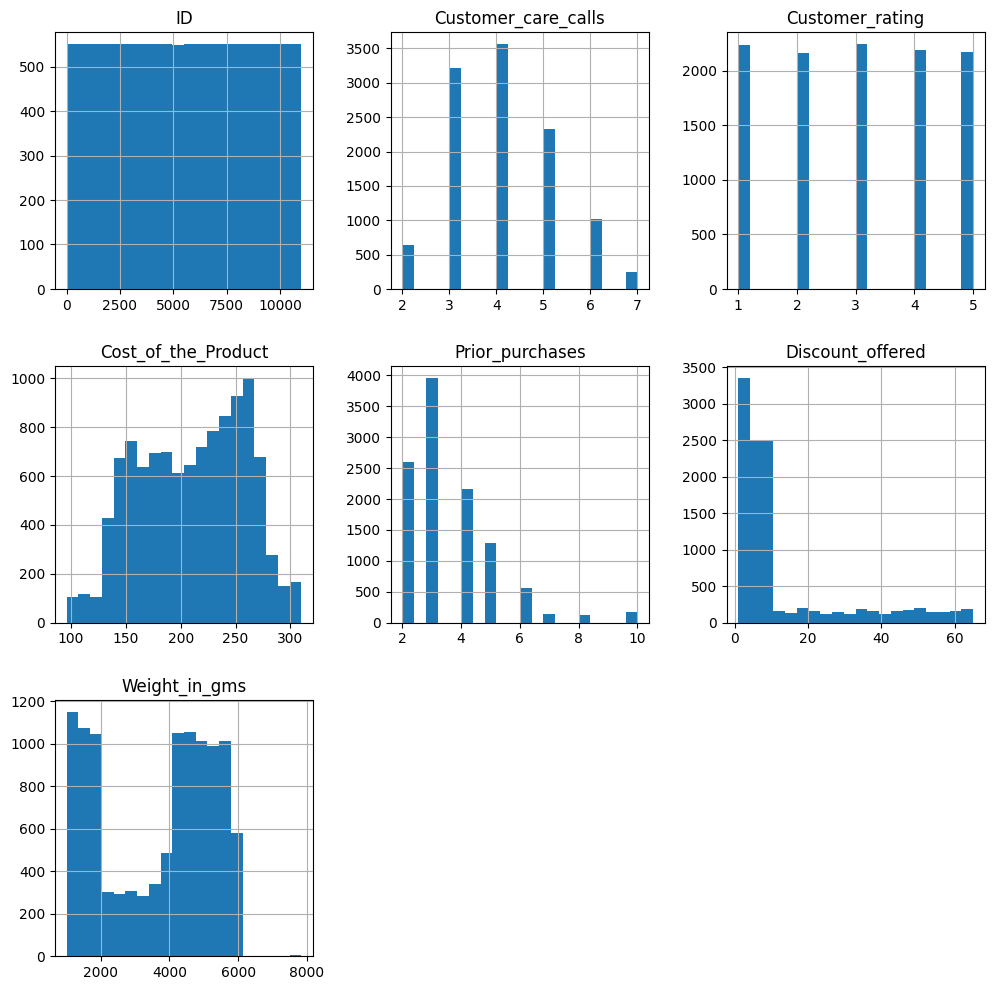

In [16]:
q_data.hist(figsize=(12,12), bins = 20)
plt.show()

## Box-plot

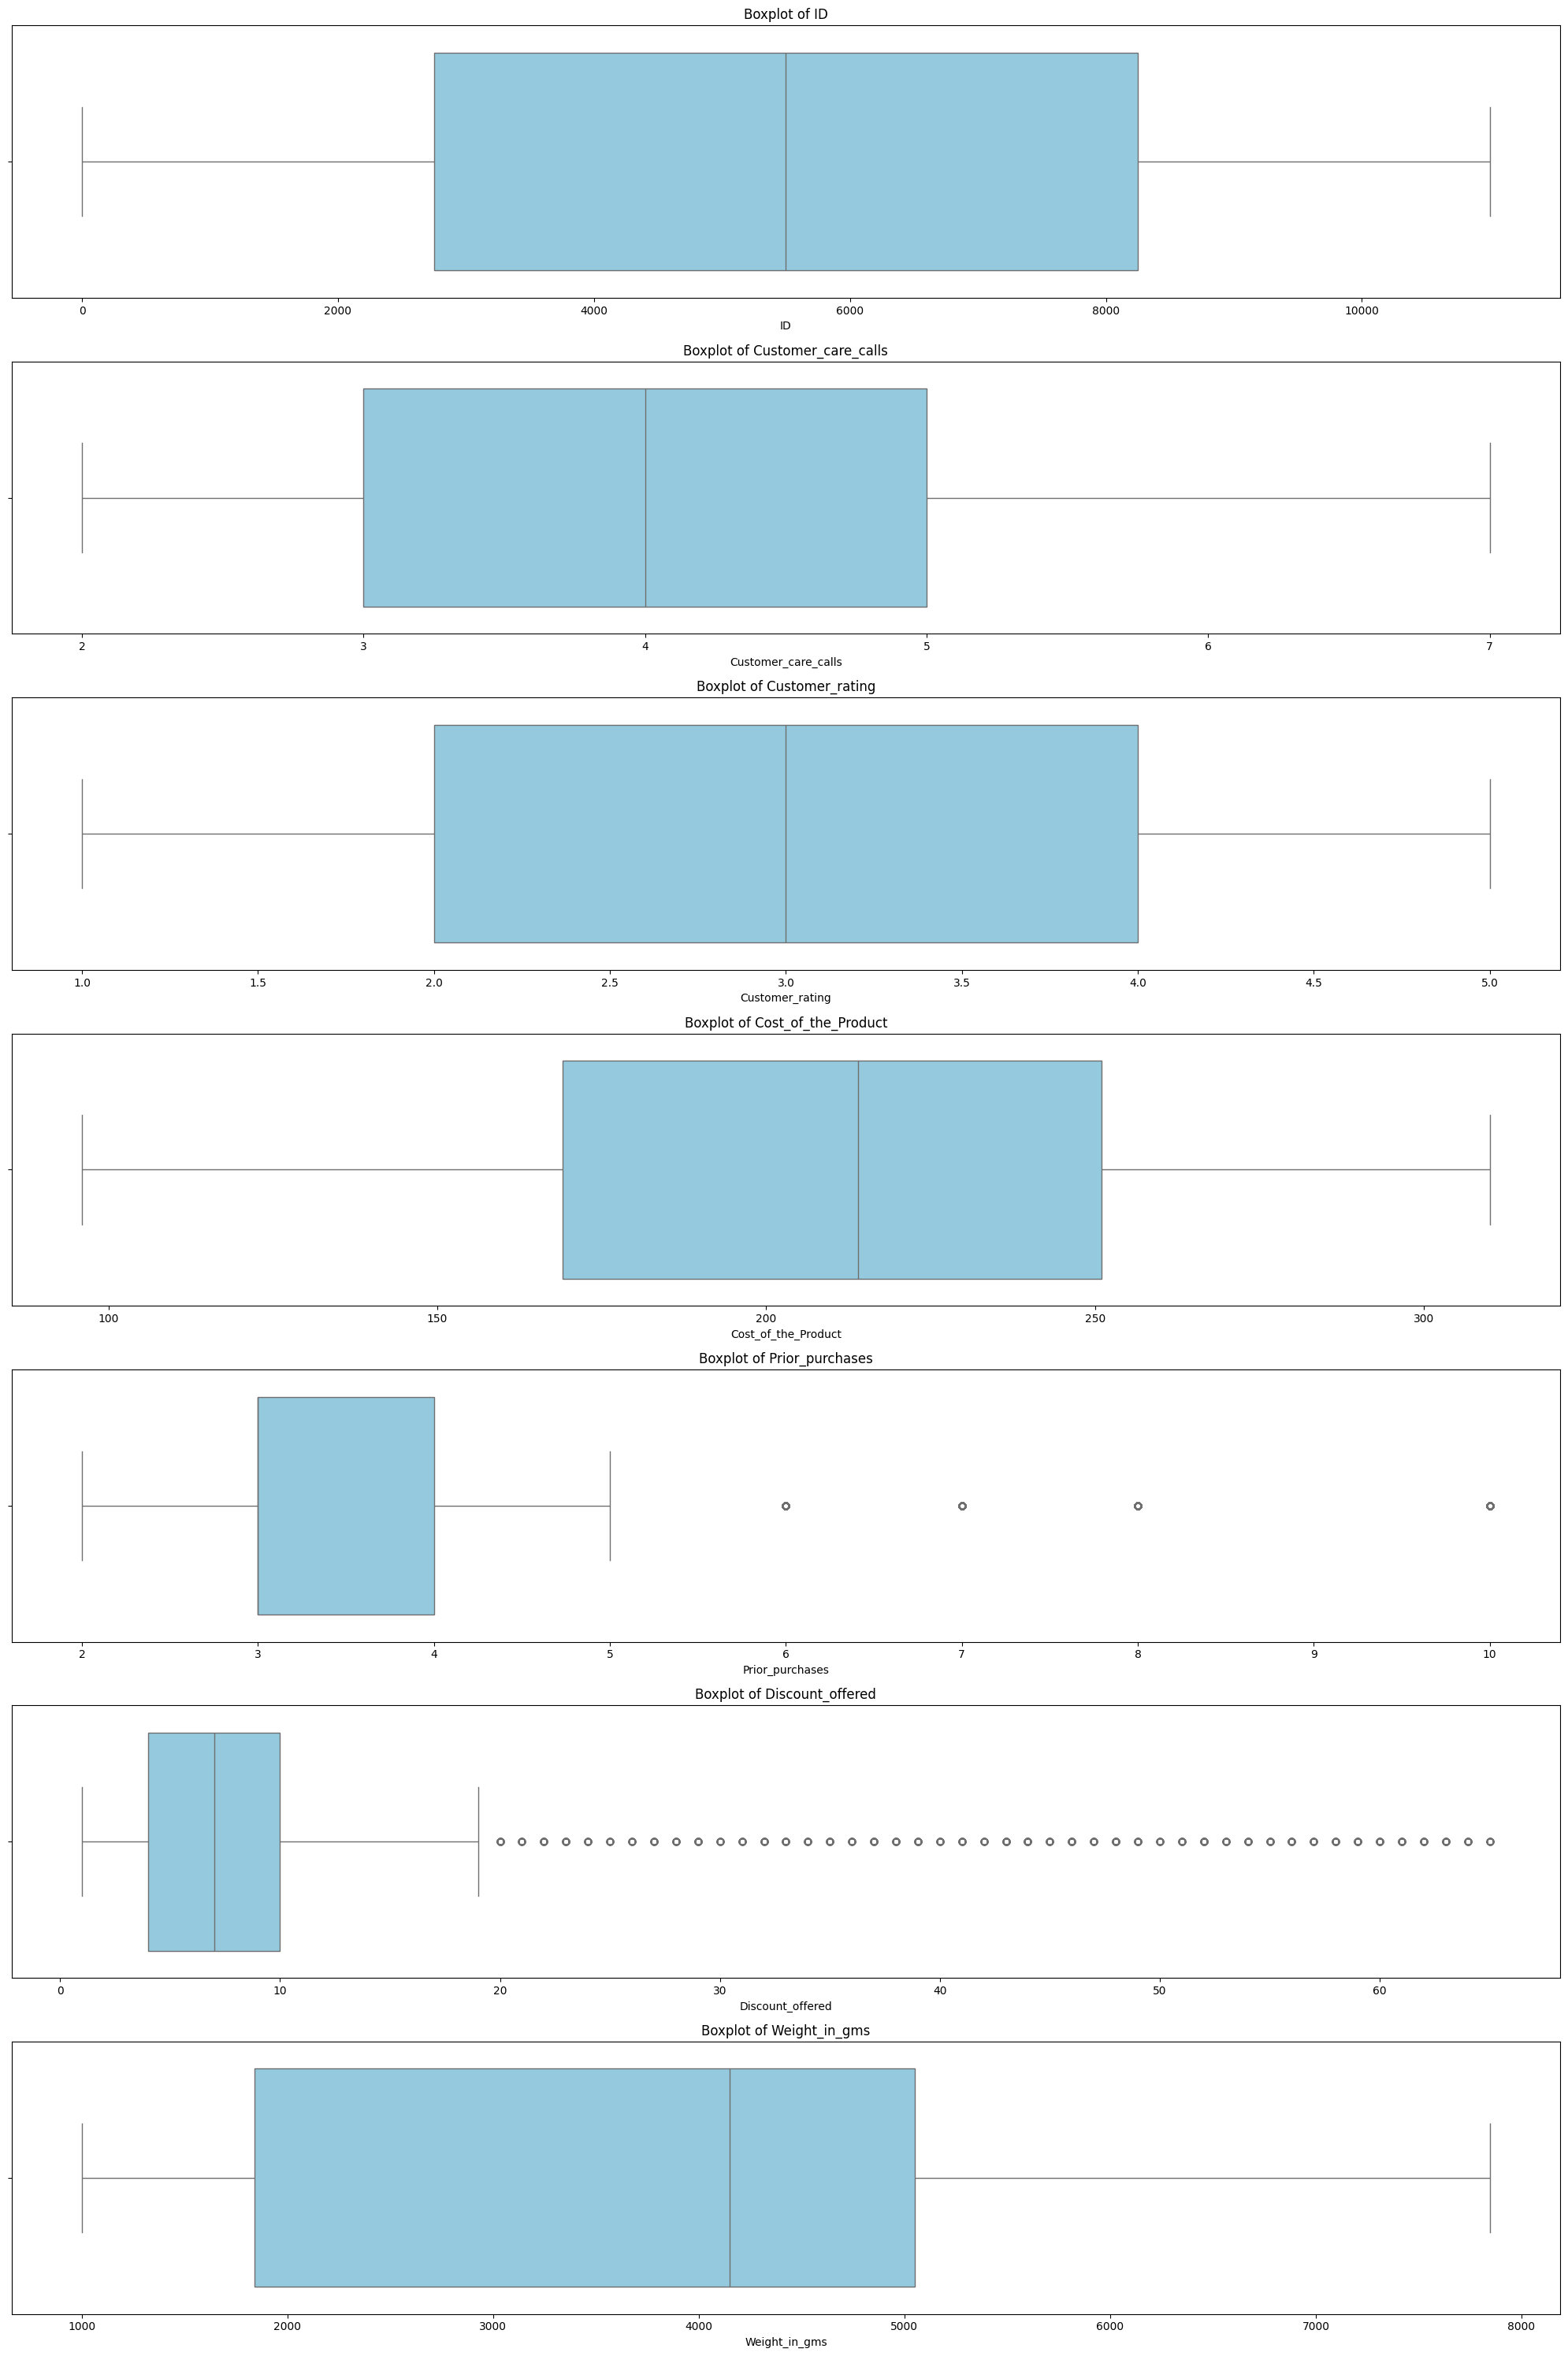

In [17]:
q_columns = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(20,30))
#our target variable is reached on time
for i, c in enumerate(q_columns, 1):
    plt.subplot(len(q_columns), 1, i)
    sns.boxplot(x=df[c], color='skyblue')
    plt.title(f'Boxplot of {c}', fontsize=12)
    plt.tight_layout()
plt.show()

In [18]:
q_data.nunique()

,0
ID,10999
Customer_care_calls,6
Customer_rating,5
Cost_of_the_Product,215
Prior_purchases,8
Discount_offered,65
Weight_in_gms,4034


In [19]:
q_data.isnull().sum()

,0
ID,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Discount_offered,0
Weight_in_gms,0


In [20]:
print(c_data.nunique())

Warehouse_block        5
Mode_of_Shipment       3
Product_importance     3
Gender                 2
Reached.on.Time_Y.N    2
dtype: int64


## Barplot of unique value counts in categorical features

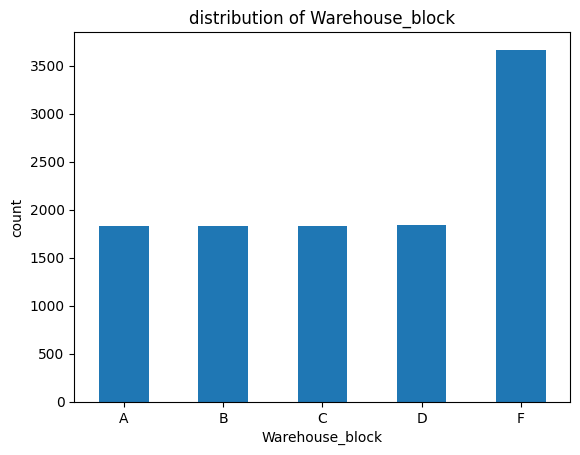

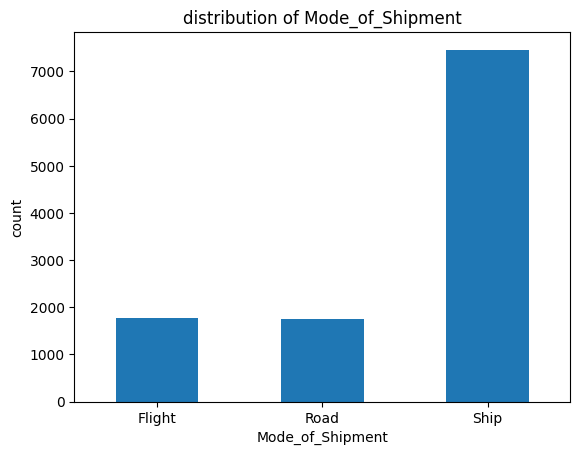

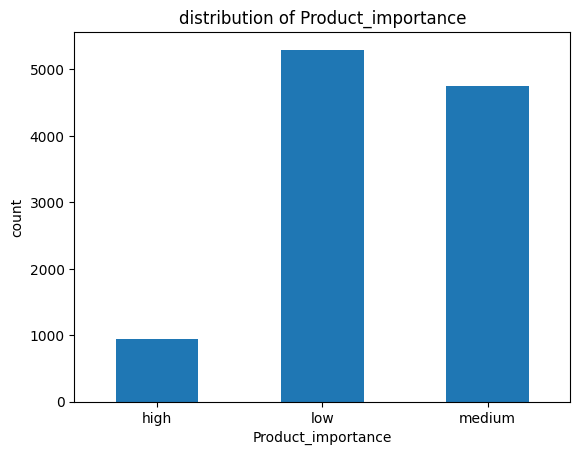

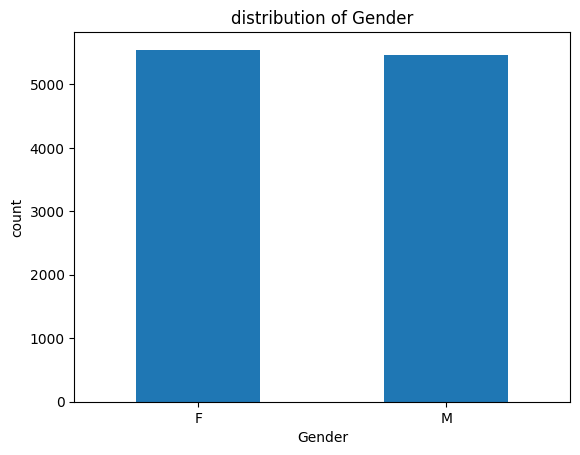

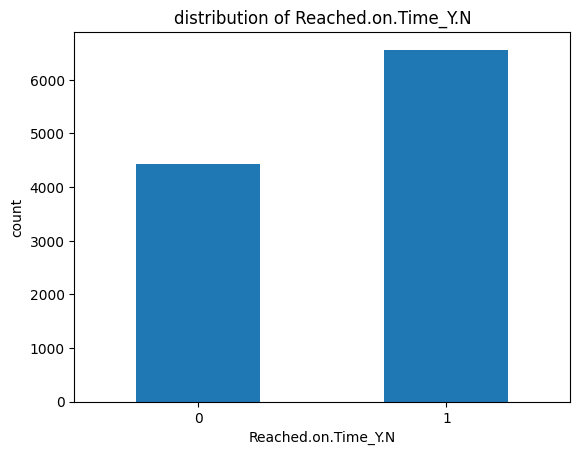

In [21]:
for c in c_features:
    plt.title(f'distribution of {c}')
    c_data[c].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=c, ylabel= 'count')
    plt.show()

## Correlation Analysis

In [22]:
# converting Reached.on.Time_Y.N as int for correlation analysis
df['Reached.on.Time_Y.N'] = df['Reached.on.Time_Y.N'].astype(int)
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


(10999, 12)

In [23]:
q_data_corr = df.select_dtypes(include='number')
matrix = q_data_corr.corr()
matrix

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
ID,1.000000,0.188998,-0.005722,0.196791,0.145369,-0.598278,0.278312,-0.411822
Customer_care_calls,0.188998,1.000000,0.012209,0.323182,0.180771,-0.130750,-0.276615,-0.067126
Customer_rating,-0.005722,0.012209,1.000000,0.009270,0.013179,-0.003124,-0.001897,0.013119
Cost_of_the_Product,0.196791,0.323182,0.009270,1.000000,0.123676,-0.138312,-0.132604,-0.073587
Prior_purchases,0.145369,0.180771,0.013179,0.123676,1.000000,-0.082769,-0.168213,-0.055515
Discount_offered,-0.598278,-0.130750,-0.003124,-0.138312,-0.082769,1.000000,-0.376067,0.397108
Weight_in_gms,0.278312,-0.276615,-0.001897,-0.132604,-0.168213,-0.376067,1.000000,-0.268793
Reached.on.Time_Y.N,-0.411822,-0.067126,0.013119,-0.073587,-0.055515,0.397108,-0.268793,1.000000


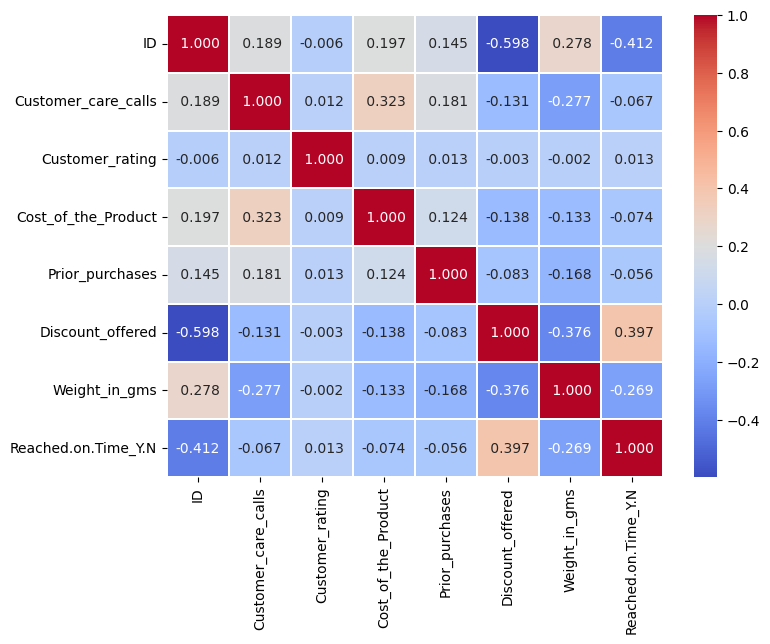

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=' .3f', linewidths = 0.3)
plt.show()

## Correlation between quantitative features and target using different methods

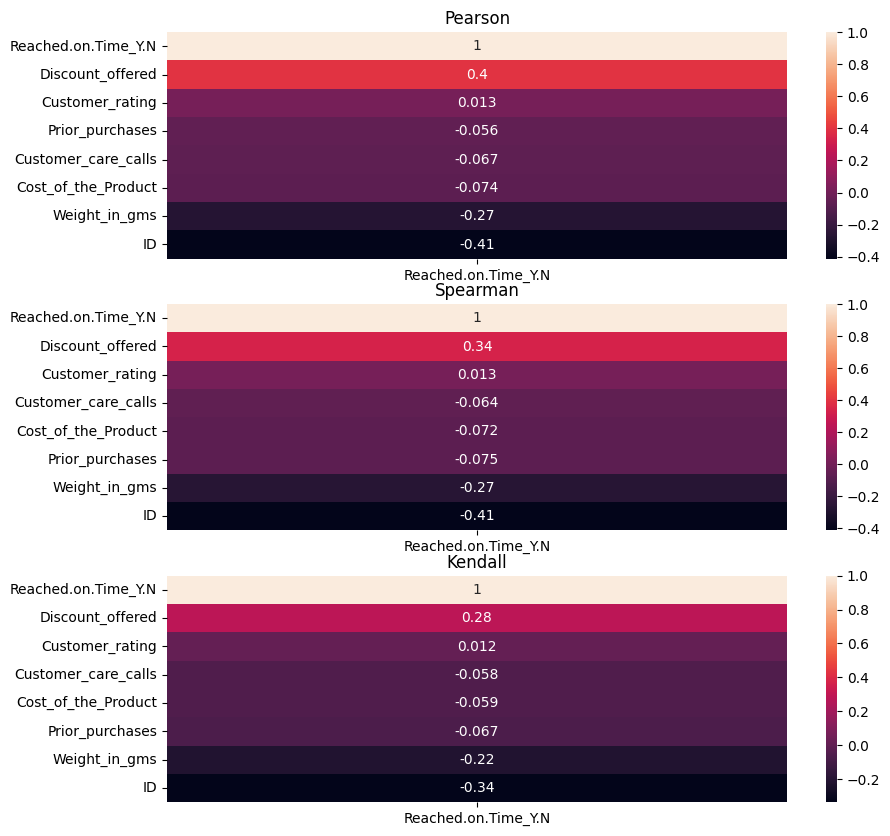

In [25]:
fig, ax = plt.subplots(3,1, figsize = (10,10))
corr1 = q_data_corr.corr('pearson')[['Reached.on.Time_Y.N']].sort_values(by= 'Reached.on.Time_Y.N', ascending =False)
corr2 = q_data_corr.corr('spearman')[['Reached.on.Time_Y.N']].sort_values(by= 'Reached.on.Time_Y.N', ascending =False)
corr3 = q_data_corr.corr('kendall')[['Reached.on.Time_Y.N']].sort_values(by= 'Reached.on.Time_Y.N', ascending =False)

ax[0].set_title('Pearson')
ax[1].set_title('Spearman')
ax[2].set_title('Kendall')

sns.heatmap(corr1, ax=ax[0], annot=True)
sns.heatmap(corr2, ax=ax[1], annot=True)
sns.heatmap(corr3, ax=ax[2], annot=True)

plt.show()

## Imbalance Check

In [26]:
class_counts = df.groupby('Reached.on.Time_Y.N').size()
columns = ['Reached.on.Time_Y.N', 'count', 'percentage']
target = [0,1]
count = list()
percentage = list()

for i in range(2):
    count.append(class_counts[i])
    percent = (class_counts[i]/10999)*100
    percentage.append(percent)

imbalance_df = pd.DataFrame(list(zip(target,count,percentage)),columns=columns)
imbalance_df


,Reached.on.Time_Y.N,count,percentage
0,0,4436,40.330939
1,1,6563,59.669061


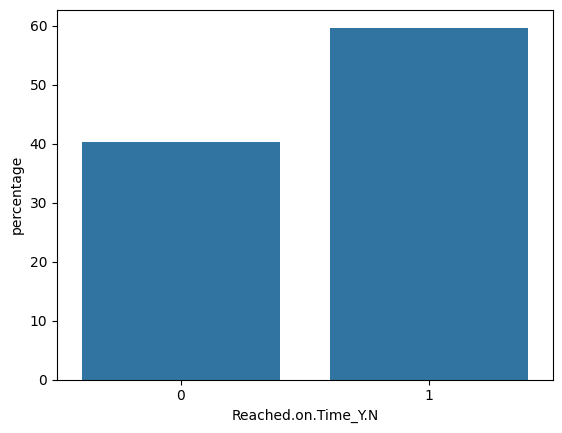

In [27]:
sns.barplot(data=imbalance_df,x=imbalance_df['Reached.on.Time_Y.N'],y=imbalance_df['percentage'])
plt.show()

In [28]:
# setting Reached.on.Time_Y.N datatype to object again
df['Reached.on.Time_Y.N'] = df['Reached.on.Time_Y.N'].astype('object')

## Density plot

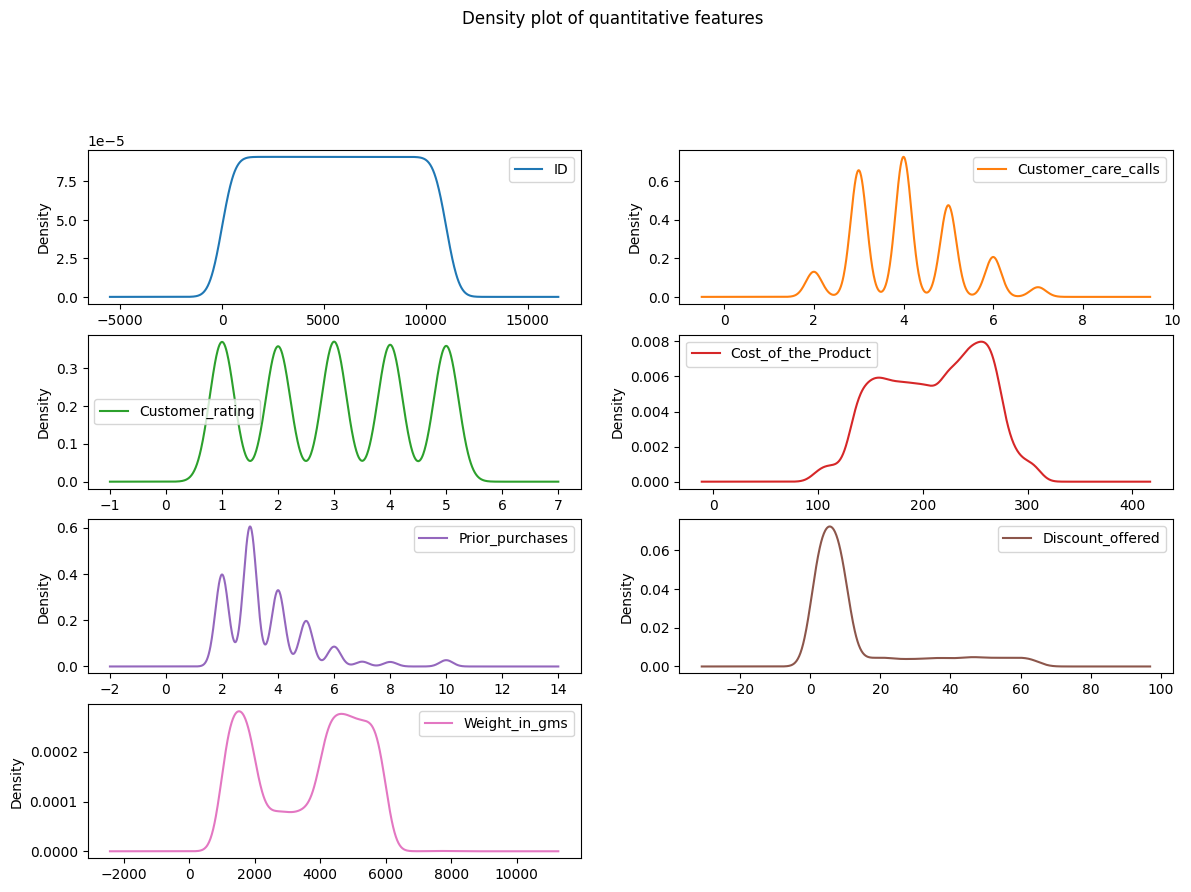

In [29]:
q_data.plot(kind='density',figsize=(14,14),subplots=True,layout=(6,2),title="Density plot of quantitative features",sharex=False)
plt.show()

# **Data Preprocessing**

## Fault 1: Irrelevant feature

In [30]:
df = df.drop(['ID'], axis=1)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Warehouse_block      10999 non-null  object
 1   Mode_of_Shipment     10999 non-null  object
 2   Customer_care_calls  10999 non-null  int64 
 3   Customer_rating      10999 non-null  int64 
 4   Cost_of_the_Product  10999 non-null  int64 
 5   Prior_purchases      10999 non-null  int64 
 6   Product_importance   10999 non-null  object
 7   Gender               10999 non-null  object
 8   Discount_offered     10999 non-null  int64 
 9   Weight_in_gms        10999 non-null  int64 
 10  Reached.on.Time_Y.N  10999 non-null  object
dtypes: int64(6), object(5)
memory usage: 945.4+ KB


## Fault 2: Categorical data

### One hot encoding

In [32]:
cols_to_onehotencode = ['Warehouse_block', 'Mode_of_Shipment']
# drop_first=True drops the first class to reduce columns and complexity
df_enc = pd.get_dummies(df, columns=cols_to_onehotencode, drop_first=True)

In [33]:
df_enc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Customer_care_calls    10999 non-null  int64 
 1   Customer_rating        10999 non-null  int64 
 2   Cost_of_the_Product    10999 non-null  int64 
 3   Prior_purchases        10999 non-null  int64 
 4   Product_importance     10999 non-null  object
 5   Gender                 10999 non-null  object
 6   Discount_offered       10999 non-null  int64 
 7   Weight_in_gms          10999 non-null  int64 
 8   Reached.on.Time_Y.N    10999 non-null  object
 9   Warehouse_block_B      10999 non-null  bool  
 10  Warehouse_block_C      10999 non-null  bool  
 11  Warehouse_block_D      10999 non-null  bool  
 12  Warehouse_block_F      10999 non-null  bool  
 13  Mode_of_Shipment_Road  10999 non-null  bool  
 14  Mode_of_Shipment_Ship  10999 non-null  bool  
dtypes: bool(6), int64(6

### Label encoding

In [34]:
df_enc['Product_importance'] = df_enc['Product_importance'].map({'low': 1, 'medium': 2, 'high': 3})
df_enc['Gender'] = df_enc['Gender'].map({'F': 0, 'M': 1})

In [35]:
df_enc[['Product_importance', 'Gender']].head(15)

,Product_importance,Gender
0,1,0
1,1,1
2,1,1
3,2,1
4,2,0
5,2,0
6,1,0
7,1,0
8,1,0
9,2,0


### Changing data type

In [36]:
df_enc['Reached.on.Time_Y.N'] = df_enc['Reached.on.Time_Y.N'].astype('int64')

In [37]:
df_enc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Customer_care_calls    10999 non-null  int64
 1   Customer_rating        10999 non-null  int64
 2   Cost_of_the_Product    10999 non-null  int64
 3   Prior_purchases        10999 non-null  int64
 4   Product_importance     10999 non-null  int64
 5   Gender                 10999 non-null  int64
 6   Discount_offered       10999 non-null  int64
 7   Weight_in_gms          10999 non-null  int64
 8   Reached.on.Time_Y.N    10999 non-null  int64
 9   Warehouse_block_B      10999 non-null  bool 
 10  Warehouse_block_C      10999 non-null  bool 
 11  Warehouse_block_D      10999 non-null  bool 
 12  Warehouse_block_F      10999 non-null  bool 
 13  Mode_of_Shipment_Road  10999 non-null  bool 
 14  Mode_of_Shipment_Ship  10999 non-null  bool 
dtypes: bool(6), int64(9)
memory usage: 8

# Dataset splitting

Before we proceed with any transformations or scaling, we need to split the data into train and test.

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
#for safety
df_new = df_enc.copy()
x = df_new.drop(columns = "Reached.on.Time_Y.N")
y = df_new['Reached.on.Time_Y.N']
#using 80-20 training-testing set
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, stratify = y, random_state = 42)

In [40]:
x_train

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship
7920,4,1,261,2,2,0,9,4158,False,False,True,False,True,False
1529,3,3,162,2,1,0,26,1659,False,False,False,True,False,True
10521,3,2,221,2,2,1,9,4466,True,False,False,False,False,True
9558,3,5,157,4,2,0,2,4640,False,False,True,False,False,True
968,2,5,272,2,1,1,24,3638,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,4,4,204,3,1,0,9,4757,True,False,False,False,True,False
4876,4,2,237,3,1,0,7,4785,False,True,False,False,False,True
3708,4,1,140,4,1,1,6,5067,False,False,True,False,False,False
6201,4,4,251,2,2,0,6,4376,True,False,False,False,False,True


In [41]:
print(y_train.value_counts())
print(y_test.value_counts())

Reached.on.Time_Y.N
1    5250
0    3549
Name: count, dtype: int64
Reached.on.Time_Y.N
1    1313
0     887
Name: count, dtype: int64


## Fault 3: Skewness and outliers

In [42]:
x_train_transform_scale = x_train.copy()
x_test_transform_scale = x_test.copy()

### Step 1: Log transformation

In [43]:
cols_to_transform_scale = ['Prior_purchases', 'Discount_offered']
x_train_transform_scale[cols_to_transform_scale] = np.log1p(x_train_transform_scale[cols_to_transform_scale])
x_test_transform_scale[cols_to_transform_scale] = np.log1p(x_test_transform_scale[cols_to_transform_scale])

In [44]:
print("Before transformation:")
print(x_train[cols_to_transform_scale].skew())
print()
print("After transformation:")
print(x_train_transform_scale[cols_to_transform_scale].skew())

Before transformation:
Prior_purchases     1.682027
Discount_offered    1.796737
dtype: float64

After transformation:
Prior_purchases     0.670175
Discount_offered    0.526786
dtype: float64


### Step 2: Robust scaling

In [45]:
from sklearn.preprocessing import RobustScaler

In [46]:
robust_scaler = RobustScaler()
x_train_transform_scale[cols_to_transform_scale] = robust_scaler.fit_transform(x_train_transform_scale[cols_to_transform_scale])
x_test_transform_scale[cols_to_transform_scale] = robust_scaler.fit_transform(x_test_transform_scale[cols_to_transform_scale])

In [47]:
print("Before Scaling:")
x_train[cols_to_transform_scale].describe().T

Before Scaling:


,count,mean,std,min,25%,50%,75%,max
Prior_purchases,8799.0,3.581998,1.532722,2.0,3.0,3.0,4.0,10.0
Discount_offered,8799.0,13.366974,16.147015,1.0,4.0,7.0,10.0,65.0


In [48]:
print("After Scaling:")
x_train_transform_scale[cols_to_transform_scale].describe().T

After Scaling:


,count,mean,std,min,25%,50%,75%,max
Prior_purchases,8799.0,0.398812,1.327300,-1.289224,0.000000,0.0,1.000000,4.533409
Discount_offered,8799.0,0.139850,1.180282,-1.758236,-0.596105,0.0,0.403895,2.676382


## Fault 4: Feature scaling

In [49]:
from sklearn.preprocessing import StandardScaler

In [50]:
x_train_scaled = x_train_transform_scale.copy()
x_test_scaled = x_test_transform_scale.copy()
cols_to_scale = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Weight_in_gms']

In [51]:
std_scaler = StandardScaler()
x_train_scaled[cols_to_scale] = std_scaler.fit_transform(x_train_scaled[cols_to_scale])
x_test_scaled[cols_to_scale] = std_scaler.fit_transform(x_test_scaled[cols_to_scale])

In [52]:
print("Before Scaling:")
x_train[cols_to_scale].describe().T

Before Scaling:


,count,mean,std,min,25%,50%,75%,max
Customer_care_calls,8799.0,4.049096,1.138649,2.0,3.0,4.0,5.0,7.0
Customer_rating,8799.0,2.997386,1.411194,1.0,2.0,3.0,4.0,5.0
Cost_of_the_Product,8799.0,210.230367,48.051317,96.0,170.0,214.0,251.0,310.0
Weight_in_gms,8799.0,3631.227867,1634.180615,1001.0,1838.0,4140.0,5045.0,7846.0


In [53]:
print("After Scaling:")
x_train_scaled[cols_to_scale].describe().T

After Scaling:


,count,mean,std,min,25%,50%,75%,max
Customer_care_calls,8799.0,-2.002666e-16,1.000057,-1.799688,-0.921405,-0.043121,0.835163,2.591731
Customer_rating,8799.0,1.615053e-17,1.000057,-1.415468,-0.706808,0.001852,0.710512,1.419173
Cost_of_the_Product,8799.0,2.200510e-16,1.000057,-2.377393,-0.837285,0.078455,0.848508,2.076432
Weight_in_gms,8799.0,-2.139946e-17,1.000057,-1.609600,-1.097388,0.311349,0.865175,2.579281


In [54]:
x_train_scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8799 entries, 7920 to 7187
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_care_calls    8799 non-null   float64
 1   Customer_rating        8799 non-null   float64
 2   Cost_of_the_Product    8799 non-null   float64
 3   Prior_purchases        8799 non-null   float64
 4   Product_importance     8799 non-null   int64  
 5   Gender                 8799 non-null   int64  
 6   Discount_offered       8799 non-null   float64
 7   Weight_in_gms          8799 non-null   float64
 8   Warehouse_block_B      8799 non-null   bool   
 9   Warehouse_block_C      8799 non-null   bool   
 10  Warehouse_block_D      8799 non-null   bool   
 11  Warehouse_block_F      8799 non-null   bool   
 12  Mode_of_Shipment_Road  8799 non-null   bool   
 13  Mode_of_Shipment_Ship  8799 non-null   bool   
dtypes: bool(6), float64(6), int64(2)
memory usage: 670.2 KB


In [55]:
x_train_scaled.head()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship
7920,-0.043121,-1.415468,1.056631,-1.289224,2,0,0.283013,0.322365,False,False,True,False,True,False
1529,-0.921405,0.001852,-1.003783,-1.289224,1,0,1.542753,-1.206929,False,False,False,True,False,True
10521,-0.921405,-0.706808,0.224140,-1.289224,2,1,0.283013,0.510849,True,False,False,False,False,True
9558,-0.921405,1.419173,-1.107845,1.000000,2,0,-1.243985,0.617330,False,False,True,False,False,True
968,-1.799688,1.419173,1.285566,-1.289224,1,1,1.445144,0.004144,False,False,False,False,False,False


## Neural Network

Training

In [62]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

In [63]:
from sklearn.utils import class_weight

In [64]:
weights = class_weight.compute_class_weight('balanced',
                                            classes=np.unique(y_train),
                                            y=y_train)
class_weights_dict = dict(enumerate(weights))

In [65]:
model = Sequential([
    Dense(64, activation='relu', input_dim = x_train_scaled.shape[1]),
    Dense(32, activation ='relu'),
    Dense(1, activation ='sigmoid')
])

model.compile(optimizer=Adam(0.001), loss=BinaryCrossentropy, metrics = ['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')])
history = model.fit(x_train_scaled, y_train, epochs = 50, batch_size = 32, class_weight=class_weights_dict)

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


275/275 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6464 - auc: 0.7134 - loss: 0.5774 - precision: 0.8232 - recall: 0.5189
Epoch 2/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6628 - auc: 0.7320 - loss: 0.5324 - precision: 0.9177 - recall: 0.4777
Epoch 3/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6679 - auc: 0.7416 - loss: 0.5237 - precision: 0.9446 - recall: 0.4710
Epoch 4/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6701 - auc: 0.7462 - loss: 0.5205 - precision: 0.9536 - recall: 0.4699
Epoch 5/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6712 - auc: 0.7524 - loss: 0.5174 - precision: 0.9555 - recall: 0.4709
Epoch 6/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6769 - auc: 0.7527 - loss: 0.5153 - precision: 0.9585 - recall: 0.4792
Epoch 7/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6750 - auc: 0.7562 - loss: 0.5136 - precision: 0.9568 - recall: 0.4768
Epoch 8/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step 

Evaluation

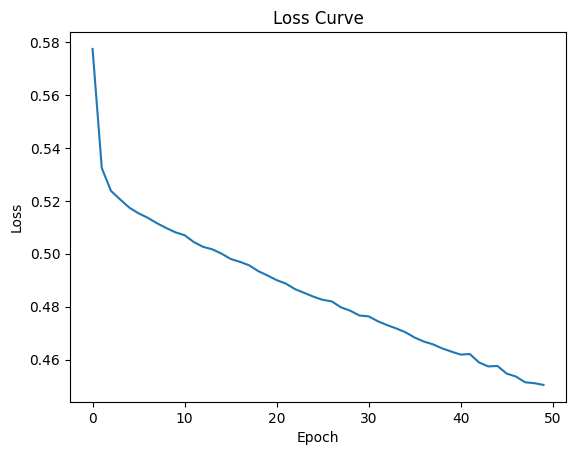

In [66]:
plt.plot(history.history['loss'])
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [67]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc

In [68]:
train_eval = model.evaluate(x_train_scaled,y_train)
print(f'Training Accuracy: {train_eval[1]*100:.2f}%')

275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7475 - auc: 0.8544 - loss: 0.4498 - precision: 0.9199 - recall: 0.6318
Training Accuracy: 74.75%


In [69]:
results = model.evaluate(x_test_scaled, y_test)
print(f"Test Accuracy: {results[1]*100:.2f}%")
print(f"Test AUC: {results[2]:.4f}")
print(f"Test Precision: {results[3]:.4f}")
print(f"Test Recall: {results[4]:.4f}")

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6668 - auc: 0.7368 - loss: 0.5567 - precision: 0.8040 - recall: 0.5842
Test Accuracy: 66.68%
Test AUC: 0.7368
Test Precision: 0.8040
Test Recall: 0.5842


In [70]:
#confusion matrix
y_predicted = model.predict(x_test_scaled).astype(int)
print('Confusion Matrix on test data:')
print(confusion_matrix(y_test, y_predicted))

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix on test data:
[[887   0]
 [833 480]]


# Naive Bayes Classifier

In [71]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(x_train_scaled, y_train)

print("Training accuracy of the model is {:.2f}".format(gnb.score(x_train_scaled, y_train)))
print("Testing accuracy of the model is {:.2f}".format(gnb.score(x_test_scaled, y_test)))

Training accuracy of the model is 0.65
Testing accuracy of the model is 0.65


In [72]:
y_gnb_preds = gnb.predict(x_test_scaled)
print(y_gnb_preds)

[1 0 0 ... 1 1 1]


In [73]:
from sklearn.metrics import confusion_matrix
mat=confusion_matrix(y_gnb_preds, y_test)
print(mat)

[[633 510]
 [254 803]]


In [74]:
gnb_accuracy = accuracy_score(y_test, y_gnb_preds)
gnb_precision = precision_score(y_test, y_gnb_preds)
gnb_recall = recall_score(y_test, y_gnb_preds)
gnb_auc = roc_auc_score(y_test, y_gnb_preds)

In [75]:
print(f"GNB Accuracy: {gnb_accuracy*100:.2f}%")
print(f"GNB Precision: {gnb_precision:.4f}")
print(f"GNB Recall: {gnb_recall:.4f}")
print(f"GNB AUC: {gnb_auc:.4f}")

GNB Accuracy: 65.27%
GNB Precision: 0.7597
GNB Recall: 0.6116
GNB AUC: 0.6626


<Axes: >

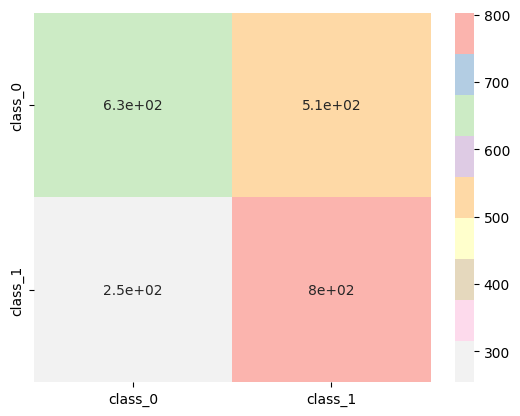

In [76]:
sns.heatmap(mat , cmap="Pastel1_r", xticklabels=['class_0' ,'class_1'], yticklabels=['class_0' ,'class_1',], annot=True)

# Logistic Regression

In [77]:
from sklearn.linear_model import LogisticRegression
logistic_regression_model =LogisticRegression()
logistic_regression_model.fit(x_train_scaled,y_train)
y_pred = logistic_regression_model.predict(x_test_scaled)
y_logistic_regression_pred = y_pred

print(f'Training Accuracy: {logistic_regression_model.score(x_train_scaled, y_train)*100:.2f}%')
print(f'Testing Accuracy:{accuracy_score(y_test,y_pred)*100:.2f}%')
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Training Accuracy: 63.33%
Testing Accuracy:62.91%
Confusion Matrix:
[[429 458]
 [358 955]]


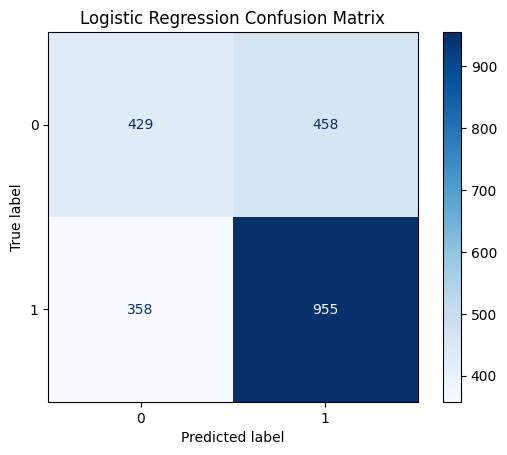

In [78]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=[0,1]).plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [79]:
logistic_regression_accuracy = accuracy_score(y_test, y_logistic_regression_pred)
logistic_regression_precision = precision_score(y_test, y_logistic_regression_pred)
logistic_regression_recall = recall_score(y_test, y_logistic_regression_pred)
logistic_regression_auc = roc_auc_score(y_test, y_logistic_regression_pred)

In [80]:
print(f"Logistic Regression Accuracy: {logistic_regression_accuracy*100:.2f}%")
print(f"Logistic Regression Precision: {logistic_regression_precision:.4f}")
print(f"Logistic Regression Recall: {logistic_regression_recall:.4f}")
print(f"Logistic Regression AUC: {logistic_regression_auc:.4f}")

Logistic Regression Accuracy: 62.91%
Logistic Regression Precision: 0.6759
Logistic Regression Recall: 0.7273
Logistic Regression AUC: 0.6055


## K-Means

In [81]:
from sklearn.cluster import KMeans
from scipy.stats import mode

In [82]:
kms = KMeans(n_clusters=2, random_state=10)
cluster_labels = kms.fit_predict(x_train_scaled)
def kms_accuracy(y_true, y_clusters):
    labels = np.zeros_like(y_clusters)
    for c in np.unique(y_clusters):
        cluster_match_arr = (y_clusters == c) #True represents the positions where the clusters match

        labels[cluster_match_arr] = mode(y_true[cluster_match_arr])[0]
    return np.mean(labels == y_true)
print(f"Training Performance: {(kms_accuracy(y_train.values, cluster_labels))*100:.2f}%")

Training Performance: 64.36%


In [83]:
print(cluster_labels)

[0 1 0 ... 0 0 0]


In [84]:
kms.cluster_centers_

array([[ 0.09928945,  0.00334745,  0.11295668,  0.51947342,  1.60156721,
         0.49276673, -0.41176757,  0.26049551,  0.17013261,  0.16666667,
         0.16847498,  0.32881254,  0.15958409,  0.67857143],
       [-0.30461619, -0.01026986, -0.3465467 ,  0.02862877,  1.62921868,
         0.48728618,  1.83219058, -0.79919011,  0.16551086,  0.16551086,
         0.16273694,  0.33656958,  0.15672677,  0.68331022]])

## Model Comparison

In [85]:
from sklearn.metrics import roc_curve, auc

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[1.         0.5980519  0.07829995 ... 0.38564512 0.58104265 1.        ]
[0.99984434 0.35414169 0.32260598 ... 0.56190453 0.53765616 0.99994324]
[0.92517432 0.35940745 0.33889963 ... 0.30074486 0.4826306  0.95726685]


<Figure size 1000x800 with 0 Axes>

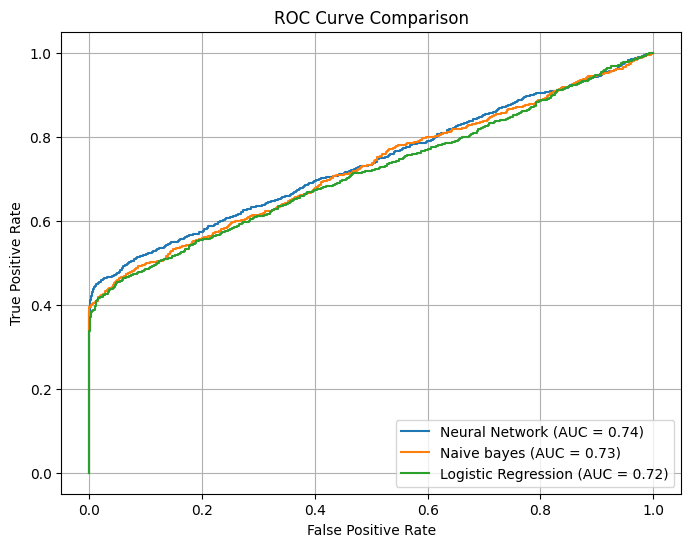

In [86]:
models = {
    'Neural Network': model,
    'Naive bayes': gnb,
    'Logistic Regression': logistic_regression_model
}
probs = {}
plt.figure(figsize=(10, 8))
for name, m in models.items():
    if name == 'Neural Network':
        probs[name] = m.predict(x_test_scaled).ravel() #for nn
    else:
        probs[name] = m.predict_proba(x_test_scaled)[:, 1]

# Plot ROC curves
plt.figure(figsize=(8,6))

for name, prob in probs.items():
    print(prob)
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Final plot setup
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid()
plt.show()


In [87]:
# model_name: [model_accuracy, model_precision, model_recall]
model_data = {
    'Neural Network': [results[1] * 100, results[3], results[4]],
    'Gaussian NB': [gnb_accuracy * 100, gnb_precision, gnb_recall],
    'Logistic Regression': [logistic_regression_accuracy * 100, logistic_regression_precision, logistic_regression_recall]
}

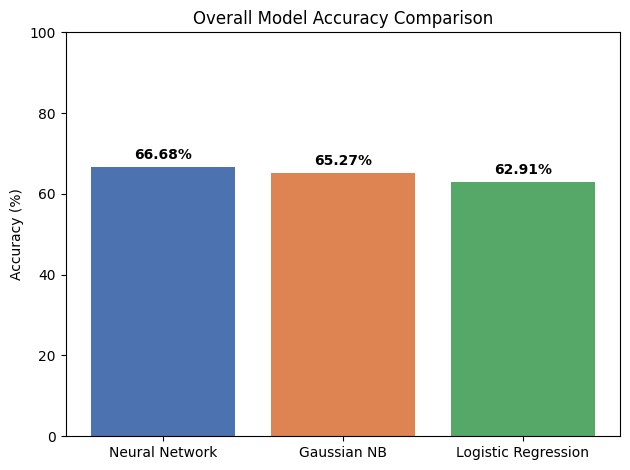

In [88]:
import matplotlib.pyplot as plt

names = list(model_data.keys())
accuracies = [val[0] for val in model_data.values()]

plt.bar(names, accuracies, color=['#4C72B0', '#DD8452', '#55A868'])

plt.ylabel('Accuracy (%)')
plt.title('Overall Model Accuracy Comparison')
plt.ylim(0, 100)


for i, v in enumerate(accuracies):
    plt.text(i, v + 2, f"{v:.2f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

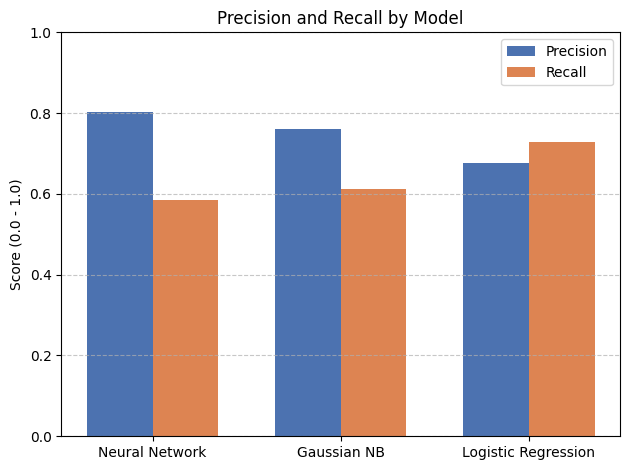

In [89]:
import matplotlib.pyplot as plt
import numpy as np

names = list(model_data.keys())
precision_scores = [val[1] for val in model_data.values()]
recall_scores = [val[2] for val in model_data.values()]

x = np.arange(len(names))
width = 0.35

plt.bar(x - width/2, precision_scores, width, label='Precision', color='#4C72B0')
plt.bar(x + width/2, recall_scores, width, label='Recall', color='#DD8452')

plt.ylabel('Score (0.0 - 1.0)')
plt.title('Precision and Recall by Model')
plt.xticks(x, names)
plt.legend()
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()